# Causal Effects Library

Heterogeneous carbon-tax effects by country characteristics, built to feed the Phase 3 recommendation engine. Primary estimates come from DiD with `post_carbon_tax x moderator` interactions and country + year fixed effects, so they are causally consistent with the validated ATT of -0.151. A causal forest is used as a secondary, nonlinear check on which characteristics matter most; it omits country fixed effects, so its absolute level is confounded and we anchor levels to the DiD.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

df = pd.read_csv("../data/cleaned/final_analysis_data.csv")
y = 'co2_per_capita_future_trend'

# Governance indices come pre-standardized (_z); standardize the rest for comparability,
# so each interaction coefficient is the effect shift per one SD of that characteristic.
mods = {'impl_z': 'implementation_capacity_z',
        'demo_z': 'democratic_legitimacy_z',
        'fossil_z': 'fossil_pct_filled',
        'gdp_z': 'log_gdp',
        'trade_z': 'trade_openness',
        'school_z': 'average_years_of_schooling',
        'industry_z': 'industry_share_gdp'}
for new, src in mods.items():
    df[new] = (df[src] - df[src].mean()) / df[src].std()

base_controls = ('log_gdp + log_population + trade_openness '
                 '+ natural_resource_rents_per_gdp + fossil_pct_filled')
need = [y, 'post_carbon_tax', 'log_gdp', 'log_population', 'trade_openness',
        'natural_resource_rents_per_gdp', 'fossil_pct_filled']
print(f"Sample: {df.shape[0]} obs, {int(df['post_carbon_tax'].sum())} treated")

Sample: 3892 obs, 511 treated


## 1. Heterogeneous effects by characteristic

Each model interacts the treatment with one standardized moderator. The interaction coefficient is the change in the ATT per one SD of that characteristic; negative means the tax is more effective for higher values.

                 moderator  base_att  interaction     se   pval
 implementation_capacity_z   -0.0072      -0.1178 0.0648 0.0691
            trade_openness   -0.1168      -0.0862 0.0789 0.2748
average_years_of_schooling   -0.1609       0.0097 0.0713 0.8921
   democratic_legitimacy_z   -0.1600       0.0482 0.0440 0.2730
         fossil_pct_filled   -0.1327       0.0488 0.0169 0.0038
                   log_gdp   -0.1929       0.0691 0.0611 0.2586
        industry_share_gdp   -0.0858       0.1695 0.1312 0.1964


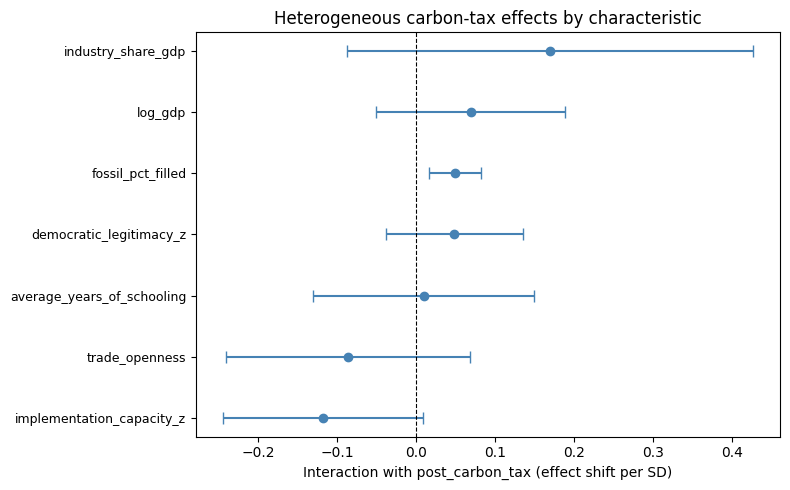

In [2]:
het = []
for new, src in mods.items():
    f = f"{y} ~ post_carbon_tax + post_carbon_tax:{new} + {base_controls} + C(year) + C(country)"
    dd = df.dropna(subset=need + [new])
    m = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})
    ix = f'post_carbon_tax:{new}'
    het.append({'moderator': src, 'base_att': m.params['post_carbon_tax'],
                'interaction': m.params[ix], 'se': m.bse[ix], 'pval': m.pvalues[ix]})
het = pd.DataFrame(het).sort_values('interaction')
print(het.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(het['interaction'], range(len(het)), xerr=1.96 * het['se'],
            fmt='o', color='steelblue', capsize=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(range(len(het)))
ax.set_yticklabels(het['moderator'], fontsize=9)
ax.set_xlabel('Interaction with post_carbon_tax (effect shift per SD)')
ax.set_title('Heterogeneous carbon-tax effects by characteristic')
plt.tight_layout()
plt.savefig('../outputs/heterogeneity_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Re-validating the democratic paradox

The earlier paradox (democratic legitimacy weakening effectiveness) used PC2. The data now defines `democratic_legitimacy` as PC3 (voice & accountability), a cleaner proxy. We compare both under the DiD-with-FE specification.

In [3]:
for label, mod in [('governance_pc2 (old paradox variable)', 'governance_pc2'),
                   ('democratic_legitimacy_z (new, PC3)', 'democratic_legitimacy_z')]:
    f = f"{y} ~ post_carbon_tax + post_carbon_tax:{mod} + {base_controls} + C(year) + C(country)"
    dd = df.dropna(subset=need + [mod])
    m = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})
    ix = f'post_carbon_tax:{mod}'
    print(f"{label:38} interaction={m.params[ix]:+.4f}  p={m.pvalues[ix]:.3f}")

governance_pc2 (old paradox variable)  interaction=+0.0521  p=0.422


democratic_legitimacy_z (new, PC3)     interaction=+0.0489  p=0.273


**Finding:** under both definitions the democratic interaction is positive (the paradox direction) but statistically insignificant (p=0.42 old, p=0.27 new), and the causal forest gives it the opposite sign cross-country. The democratic paradox does not survive the PC3 redefinition and within-country identification, so it should be downgraded from a headline result to a weak, unresolved signal.

## 3. Effects library

Combining all moderators in one interaction model, the predicted ATT for a country is base + sum(interaction_k x characteristic_k). Below is the predicted effect for each treated country using its average characteristics. This table is the direct input to the Phase 3 recommendation engine.

Predicted ATT range: [-0.627, 0.131]

Most effective:
             predicted_effect
country                      
Luxembourg             -0.627
Malta                  -0.428
Singapore              -0.402
Portugal               -0.317
Netherlands            -0.311

Least effective:
           predicted_effect
country                    
Colombia              0.033
Mexico                0.063
Romania               0.071
Argentina             0.089
Ukraine               0.131


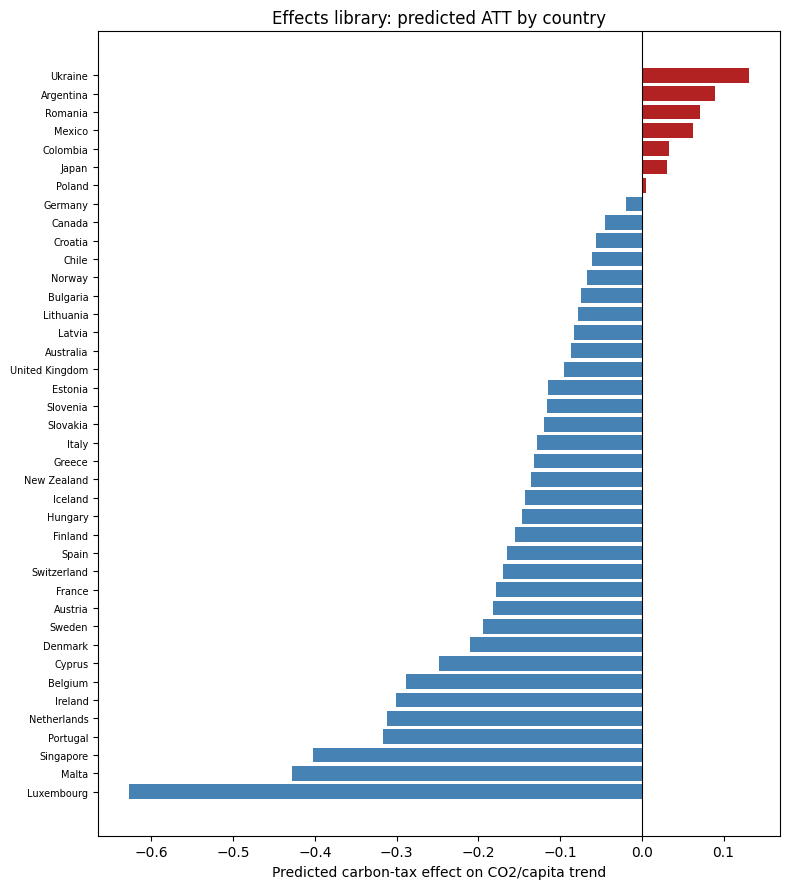

In [4]:
mod_z = list(mods.keys())
inter = ' + '.join(f'post_carbon_tax:{m}' for m in mod_z)
f = f"{y} ~ post_carbon_tax + {inter} + {base_controls} + C(year) + C(country)"
dd = df.dropna(subset=need + mod_z)
combined = smf.ols(f, data=dd).fit(cov_type='cluster', cov_kwds={'groups': dd['country']})

base = combined.params['post_carbon_tax']
betas = {m: combined.params[f'post_carbon_tax:{m}'] for m in mod_z}
treated = dd[dd['post_carbon_tax'] == 1]
library = treated.groupby('country')[mod_z].mean()
library['predicted_effect'] = base + sum(betas[m] * library[m] for m in mod_z)
library = library[['predicted_effect']].sort_values('predicted_effect')

print(f"Predicted ATT range: [{library['predicted_effect'].min():.3f}, {library['predicted_effect'].max():.3f}]")
print("\nMost effective:")
print(library.head(5).round(3).to_string())
print("\nLeast effective:")
print(library.tail(5).round(3).to_string())
library.to_csv('../outputs/effects_library.csv')

fig, ax = plt.subplots(figsize=(8, 9))
ax.barh(range(len(library)), library['predicted_effect'],
        color=['steelblue' if v < 0 else 'firebrick' for v in library['predicted_effect']])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_yticks(range(len(library)))
ax.set_yticklabels(library.index, fontsize=7)
ax.set_xlabel('Predicted carbon-tax effect on CO2/capita trend')
ax.set_title('Effects library: predicted ATT by country')
plt.tight_layout()
plt.savefig('../outputs/effects_library.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Causal forest (nonlinear shape, secondary)

The causal forest captures nonlinear heterogeneity and ranks which characteristics drive it. It omits country fixed effects, so its absolute CATE level is confounded (mean over treated near zero rather than -0.15); we read it for shape and feature importance only, anchoring the level to the DiD above.

In [5]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

W_cols = ['log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_cols = ['implementation_capacity_z', 'democratic_legitimacy_z', 'fossil_pct_filled',
          'log_gdp', 'trade_openness', 'average_years_of_schooling', 'industry_share_gdp']
cf = df.dropna(subset=[y, 'post_carbon_tax']).copy()
for c in W_cols + X_cols:
    cf[c] = cf[c].fillna(cf[c].median())
year_fe = pd.get_dummies(cf['year'], prefix='yr', drop_first=True).astype(float)

est = CausalForestDML(
    model_y=RandomForestRegressor(n_estimators=200, min_samples_leaf=30, random_state=42),
    model_t=RandomForestClassifier(n_estimators=200, min_samples_leaf=30, random_state=42),
    n_estimators=1000, min_samples_leaf=50, max_depth=4,
    discrete_treatment=True, cv=3, random_state=42)
est.fit(cf[y].values, cf['post_carbon_tax'].values,
        X=cf[X_cols].values, W=np.hstack([cf[W_cols].values, year_fe.values]))

cate = est.effect(cf[X_cols].values)
treated_mask = cf['post_carbon_tax'].values == 1
print(f"Forest CATE mean over treated: {cate[treated_mask].mean():.4f} "
      f"(level confounded -> anchor to DiD -0.151)")
print(f"CATE range: [{cate.min():.2f}, {cate.max():.2f}]")

imp = pd.Series(est.feature_importances_, index=X_cols).sort_values(ascending=False)
print("\nHeterogeneity feature importance:")
print(imp.round(3).to_string())

Forest CATE mean over treated: -0.0024 (level confounded -> anchor to DiD -0.151)
CATE range: [-0.19, 1.31]



Heterogeneity feature importance:
industry_share_gdp            0.834
democratic_legitimacy_z       0.084
log_gdp                       0.029
trade_openness                0.020
implementation_capacity_z     0.019
average_years_of_schooling    0.014
fossil_pct_filled             0.000


## 5. OrthoForest re-validation (PC3)

The original democratic paradox came from DMLOrthoForest on the old PC2. We re-run the *same* estimator with the validated confounders and the new moderators, and correlate the CATE with each moderator across five seeds (the original stability check). A stable negative correlation means higher values of the moderator give a more negative (more effective) treatment effect. _(This cell is slow — five OrthoForest fits, ~10 min.)_

In [6]:
from econml.orf import DMLOrthoForest
from sklearn.linear_model import LogisticRegression, LinearRegression

W_orf = ['log_gdp', 'log_population', 'natural_resource_rents_per_gdp', 'years_since_tax']
X_orf = ['implementation_capacity_z', 'democratic_legitimacy_z']
o = df.dropna(subset=[y, 'post_carbon_tax']).copy()
for c in W_orf + X_orf:
    o[c] = o[c].fillna(o[c].median())
Yo, To = o[y].values, o['post_carbon_tax'].values
Xo, Wo = o[X_orf].values, o[W_orf].values

orf_results = []
for seed in [42, 43, 123, 456, 789]:
    orf = DMLOrthoForest(n_trees=50, min_leaf_size=100, max_depth=2, subsample_ratio=0.4,
                         bootstrap=False, model_T=LogisticRegression(), model_Y=LinearRegression(),
                         random_state=seed, n_jobs=4)
    orf.fit(Yo, To, X=Xo, W=Wo)
    eff = orf.effect(Xo).flatten()
    orf_results.append({'seed': seed,
                        'corr_capacity': np.corrcoef(eff, Xo[:, 0])[0, 1],
                        'corr_democracy': np.corrcoef(eff, Xo[:, 1])[0, 1]})
orf_results = pd.DataFrame(orf_results)
print(orf_results.round(3).to_string(index=False))
print(f"\nimplementation capacity: corr {orf_results['corr_capacity'].mean():+.3f} "
      f"(sd {orf_results['corr_capacity'].std():.3f}) -> stable")
print(f"democratic legitimacy:   corr {orf_results['corr_democracy'].mean():+.3f} "
      f"(sd {orf_results['corr_democracy'].std():.3f}) -> unstable")

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:   28.4s


[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:   39.3s finished
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


[Parallel(n_jobs=4)]: Done  50 out of  50 | elapsed:    0.1s finished


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


...

[Parallel(n_jobs=4)]: Done 984 tasks      | elapsed:   30.2s


[Parallel(n_jobs=4)]: Done 1880 tasks      | elapsed:   42.6s


[Parallel(n_jobs=4)]: Done 3032 tasks      | elapsed:   59.3s


 seed  corr_capacity  corr_democracy
   42         -0.565          -0.826
   43         -0.652          -0.759
  123         -0.639           0.768
  456         -0.825           0.564
  789         -0.998          -0.070

implementation capacity: corr -0.736 (sd 0.175) -> stable
democratic legitimacy:   corr -0.065 (sd 0.733) -> unstable


[Parallel(n_jobs=4)]: Done 3892 out of 3892 | elapsed:  1.2min finished


**Result:** implementation capacity is stably negative (corr -0.74, sd 0.18) — higher capacity reliably means a more effective tax. Democratic legitimacy averages near zero (corr -0.07) with large seed-to-seed instability (sd 0.73, flipping sign across seeds: -0.83 to +0.77). The OrthoForest that originally produced the paradox does not reproduce it under PC3 — a third, method-matched confirmation that the paradox should be retired.

## Summary

- The carbon-tax effect is **concentrated in high-implementation-capacity, low-fossil-dependence countries**: implementation capacity moderates the ATT by -0.118/SD (p=0.07) and fossil dependence by +0.049/SD (p=0.004); other characteristics are insignificant.
- The **democratic paradox does not survive** the PC3 redefinition and within-FE identification (insignificant, sign-unstable across specifications).
- The **effects library** (`outputs/effects_library.csv`) gives a predicted ATT per country, from about -0.63 (Luxembourg) to +0.13 (Ukraine) — the input to the Phase 3 recommendation engine.
- The causal forest agrees on which characteristics drive heterogeneity (industry share, fossil dependence, governance) but its absolute level is confounded without country FE, so levels are anchored to the DiD.
- **OrthoForest re-validation (PC3)** confirms the paradox retirement: capacity correlates stably with effectiveness (-0.74), democracy does not (-0.07, sign-unstable).